# House Price Prediction

## Objective
Build a regression model to predict house prices based on property features such as area, number of bedrooms, bathrooms, and various amenities.

## Dataset
House Price Prediction Dataset — 545 residential property records with 12 features covering size, layout, location preference, and amenities.

## Approach
1. Load and inspect the dataset
2. Preprocess features (encode categorical variables, scale numeric features)
3. Perform Exploratory Data Analysis (EDA) to understand price drivers
4. Train models (Linear Regression and Gradient Boosting Regressor)
5. Evaluate using MAE, RMSE, and R² score
6. Visualize predicted vs actual prices and feature importance


### Import Libraries

Import all required libraries for data processing, visualization, and modeling.


In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully!")


All libraries imported successfully!


### Load and Explore the Dataset

Load the Housing dataset and inspect its structure, data types, and basic statistics.


In [2]:
# Load the dataset
df = pd.read_csv("Housing.csv")

# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())


Dataset shape: (545, 13)

First few rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Data types:
price               int64
area              

In [3]:
# Check for missing values and unique value counts
print("Missing values per column:")
print(df.isnull().sum())

print("\nCategorical feature unique values:")
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"  {col}: {df[col].unique()}")

print(f"\nTarget variable (price):")
print(f"  Min : ₹{df['price'].min():,.0f}")
print(f"  Max : ₹{df['price'].max():,.0f}")
print(f"  Mean: ₹{df['price'].mean():,.0f}")
print(f"  Std : ₹{df['price'].std():,.0f}")


Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Categorical feature unique values:
  mainroad: <StringArray>
['yes', 'no']
Length: 2, dtype: str
  guestroom: <StringArray>
['no', 'yes']
Length: 2, dtype: str
  basement: <StringArray>
['no', 'yes']
Length: 2, dtype: str
  hotwaterheating: <StringArray>
['no', 'yes']
Length: 2, dtype: str
  airconditioning: <StringArray>
['yes', 'no']
Length: 2, dtype: str
  prefarea: <StringArray>
['yes', 'no']
Length: 2, dtype: str
  furnishingstatus: <StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str

Target variable (price):
  Min : ₹1,750,000
  Max : ₹13,300,000
  Mean: ₹4,766,729
  Std : ₹1,870,440


### Data Cleaning and Preprocessing

Encode categorical variables and prepare features for modeling. The dataset has no missing values, so the focus is on feature encoding.

**Encoding strategy:**
- Binary columns (`yes`/`no`): map to 1/0
- `furnishingstatus` (3 classes): Label Encoding (0 = unfurnished, 1 = semi-furnished, 2 = furnished)


In [4]:
# Create a clean copy
df_clean = df.copy()

# --- Binary encoding: yes → 1, no → 0 ---
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df_clean[col] = df_clean[col].map({'yes': 1, 'no': 0})
    print(f"  '{col}' encoded → 0/1")

# --- Label encoding for furnishingstatus ---
furnish_map = {'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2}
df_clean['furnishingstatus'] = df_clean['furnishingstatus'].map(furnish_map)
print(f"  'furnishingstatus' encoded → {furnish_map}")

# --- Verify ---
print(f"\nData Cleaning Complete!")
print(f"Dataset shape : {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print("\nPreprocessed sample:")
print(df_clean.head(3))


  'mainroad' encoded → 0/1
  'guestroom' encoded → 0/1
  'basement' encoded → 0/1
  'hotwaterheating' encoded → 0/1
  'airconditioning' encoded → 0/1
  'prefarea' encoded → 0/1
  'furnishingstatus' encoded → {'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2}

Data Cleaning Complete!
Dataset shape : (545, 13)
Missing values: 0

Preprocessed sample:
      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   

   furnishingstatus  
0                 2  
1                 2  
2                

### Exploratory Data Analysis

Analyze key patterns and relationships in the data to understand what drives house prices.


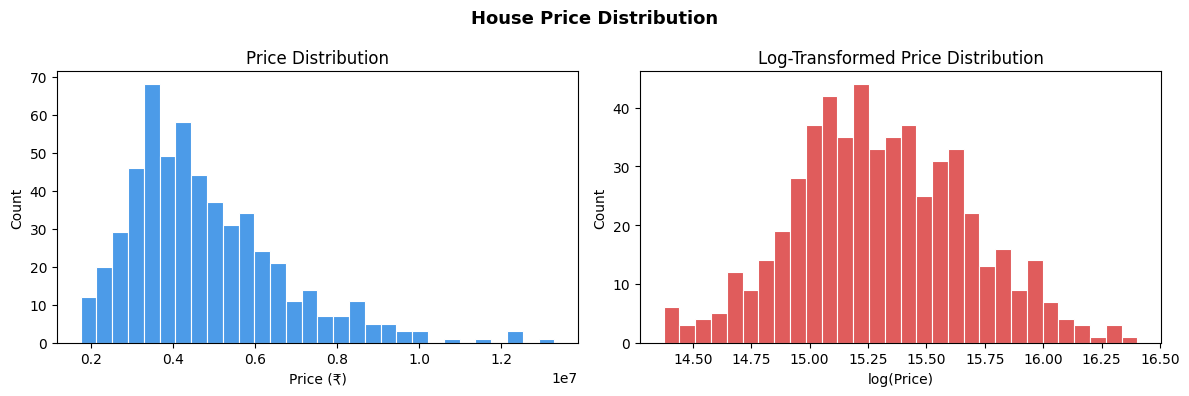

Price skewness (raw)    : 1.212
Price skewness (log)    : 0.141
Note: Log transformation reduces right skew, improving linear model performance.


In [5]:
# 1. Price distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df_clean['price'], bins=30, color='#4C9BE8', edgecolor='white', linewidth=0.8)
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Count')

# Log-scale histogram
axes[1].hist(np.log1p(df_clean['price']), bins=30, color='#E05C5C', edgecolor='white', linewidth=0.8)
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')

plt.suptitle('House Price Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Price skewness (raw)    : {df_clean['price'].skew():.3f}")
print(f"Price skewness (log)    : {np.log1p(df_clean['price']).skew():.3f}")
print("Note: Log transformation reduces right skew, improving linear model performance.")


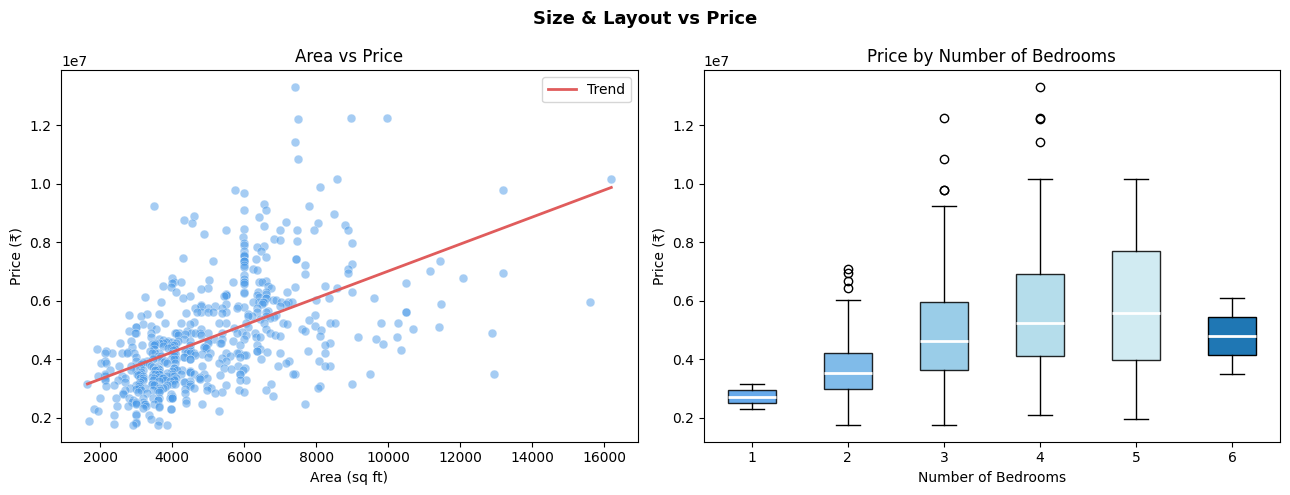

Median price by bedroom count:
bedrooms
1    2712500.0
2    3535000.0
3    4620000.0
4    5250000.0
5    5582500.0
6    4791500.0


In [6]:
# 2. Area vs Price relationship
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df_clean['area'], df_clean['price'],
                alpha=0.5, color='#4C9BE8', edgecolors='white', linewidth=0.4, s=40)
axes[0].set_xlabel('Area (sq ft)')
axes[0].set_ylabel('Price (₹)')
axes[0].set_title('Area vs Price')

# Add trend line
z = np.polyfit(df_clean['area'], df_clean['price'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['area'].min(), df_clean['area'].max(), 200)
axes[0].plot(x_line, p(x_line), color='#E05C5C', linewidth=2, label='Trend')
axes[0].legend()

# Bedrooms vs Price (box plot)
axes[1].boxplot(
    [df_clean[df_clean['bedrooms'] == b]['price'].values
     for b in sorted(df_clean['bedrooms'].unique())],
    labels=sorted(df_clean['bedrooms'].unique()),
    patch_artist=True,
    medianprops={'color': 'white', 'linewidth': 2}
)
boxes = axes[1].findobj(plt.matplotlib.patches.PathPatch)
colors_box = ['#4C9BE8', '#6AAFE6', '#88C5E4', '#A8D8E8', '#C9E8F0']
for patch, color in zip(boxes, colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
axes[1].set_xlabel('Number of Bedrooms')
axes[1].set_ylabel('Price (₹)')
axes[1].set_title('Price by Number of Bedrooms')

plt.suptitle('Size & Layout vs Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Median price by bedroom count:")
print(df_clean.groupby('bedrooms')['price'].median().to_string())


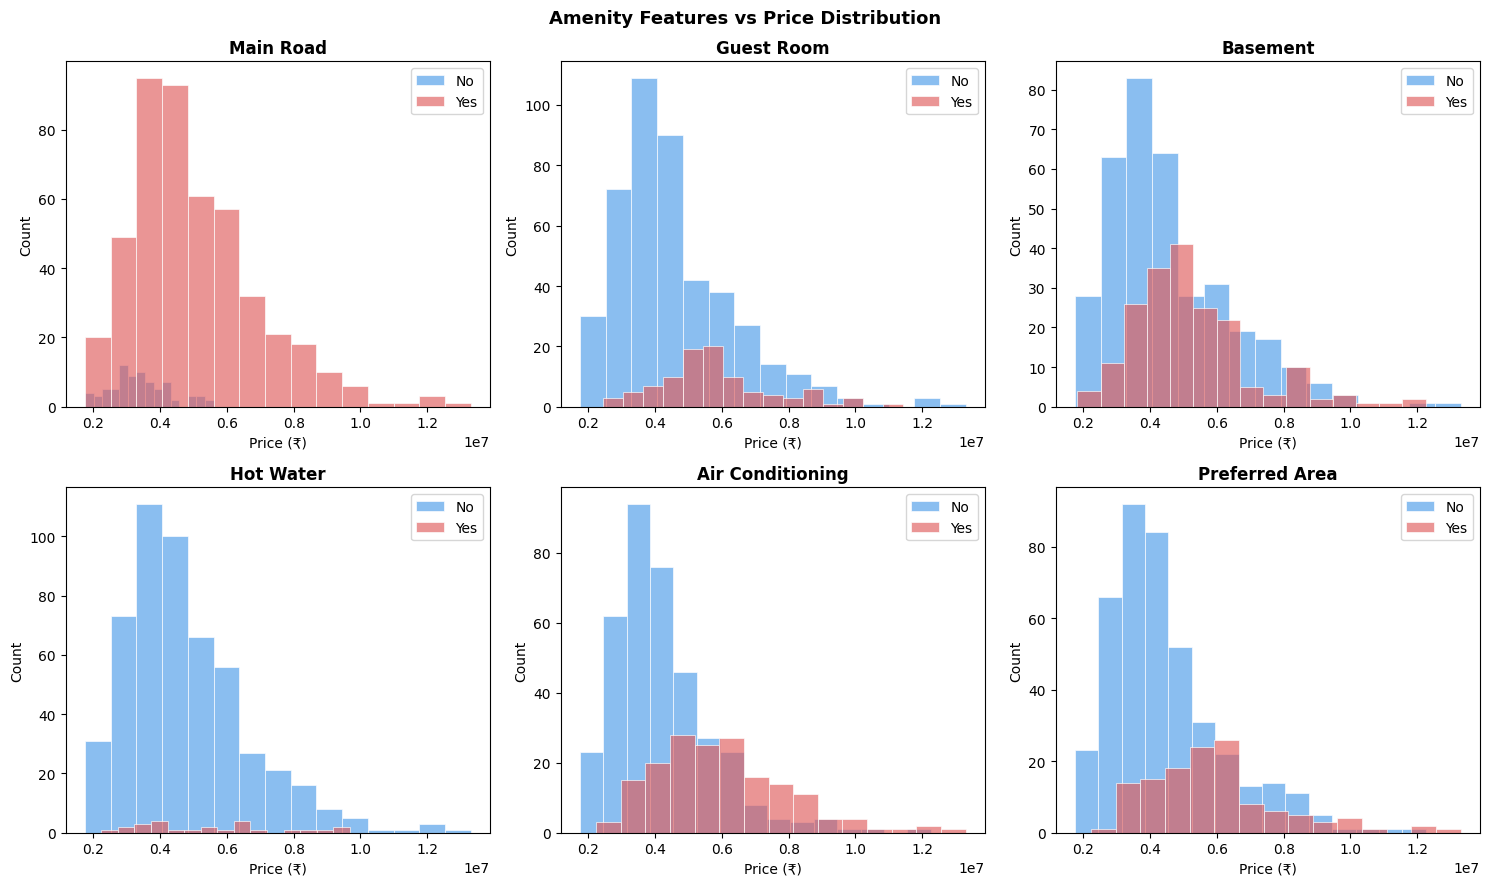

In [7]:
# 3. Amenities impact on price
amenity_cols = ['mainroad', 'guestroom', 'basement',
                'hotwaterheating', 'airconditioning', 'prefarea']
amenity_labels = ['Main Road', 'Guest Room', 'Basement',
                  'Hot Water', 'Air Conditioning', 'Preferred Area']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col, label in zip(axes, amenity_cols, amenity_labels):
    data_no  = df_clean[df_clean[col] == 0]['price']
    data_yes = df_clean[df_clean[col] == 1]['price']
    ax.hist(data_no,  bins=15, alpha=0.65, color='#4C9BE8',
            label='No',  edgecolor='white', linewidth=0.7)
    ax.hist(data_yes, bins=15, alpha=0.65, color='#E05C5C',
            label='Yes', edgecolor='white', linewidth=0.7)
    ax.set_title(f'{label}', fontweight='bold')
    ax.set_xlabel('Price (₹)')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Amenity Features vs Price Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


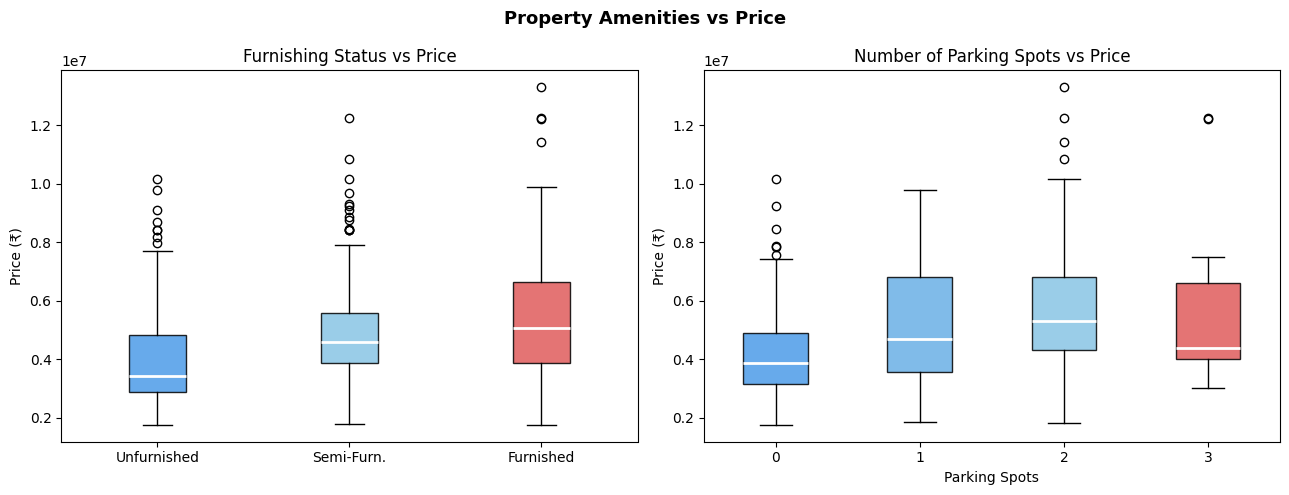

In [8]:
# 4. Furnishing status vs Price
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot
furnish_names = {0: 'Unfurnished', 1: 'Semi-Furnished', 2: 'Furnished'}
furnish_groups = [df_clean[df_clean['furnishingstatus'] == k]['price'].values
                  for k in [0, 1, 2]]
bp = axes[0].boxplot(furnish_groups, labels=['Unfurnished', 'Semi-Furn.', 'Furnished'],
                     patch_artist=True,
                     medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], ['#4C9BE8', '#88C5E4', '#E05C5C']):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
axes[0].set_title('Furnishing Status vs Price')
axes[0].set_ylabel('Price (₹)')

# Parking vs Price
parking_groups = [df_clean[df_clean['parking'] == k]['price'].values
                  for k in sorted(df_clean['parking'].unique())]
bp2 = axes[1].boxplot(parking_groups,
                      labels=[str(k) for k in sorted(df_clean['parking'].unique())],
                      patch_artist=True,
                      medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp2['boxes'], ['#4C9BE8', '#6AAFE6', '#88C5E4', '#E05C5C']):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
axes[1].set_title('Number of Parking Spots vs Price')
axes[1].set_xlabel('Parking Spots')
axes[1].set_ylabel('Price (₹)')

plt.suptitle('Property Amenities vs Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


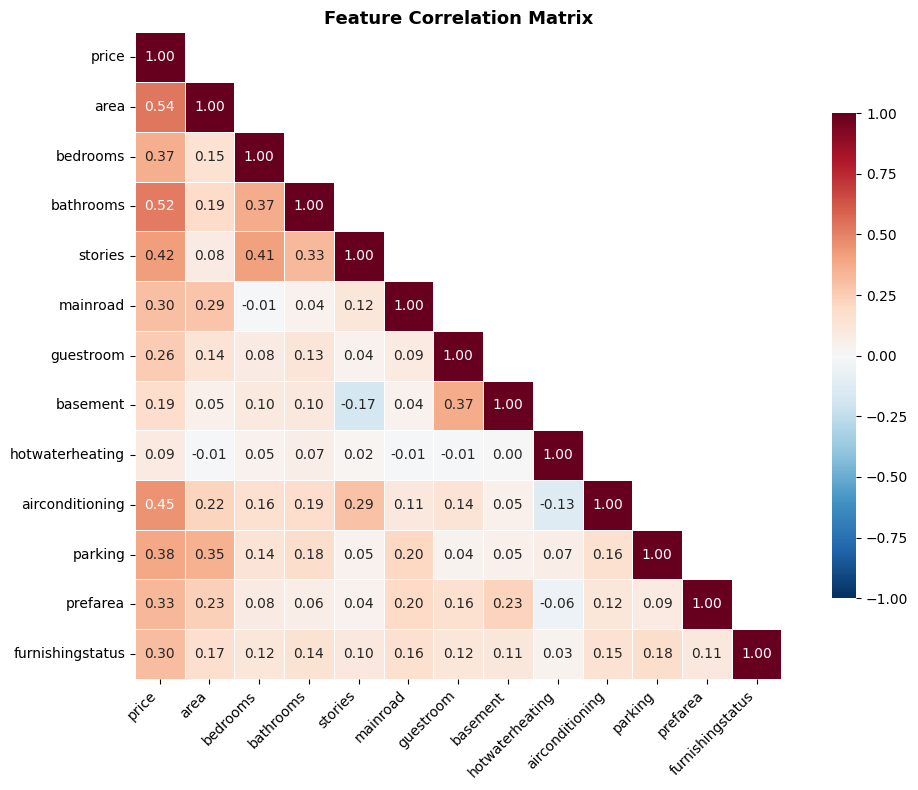

Features most correlated with price:
area                0.535997
bathrooms           0.517545
airconditioning     0.452954
stories             0.420712
parking             0.384394
bedrooms            0.366494
prefarea            0.329777
furnishingstatus    0.304721
mainroad            0.296898
guestroom           0.255517
basement            0.187057
hotwaterheating     0.093073


In [9]:
# 5. Correlation heat-map
plt.figure(figsize=(11, 8))

corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', square=True,
            cbar_kws={'shrink': 0.75})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top correlations with price
corr_price = corr['price'].drop('price').abs().sort_values(ascending=False)
print("Features most correlated with price:")
print(corr_price.to_string())


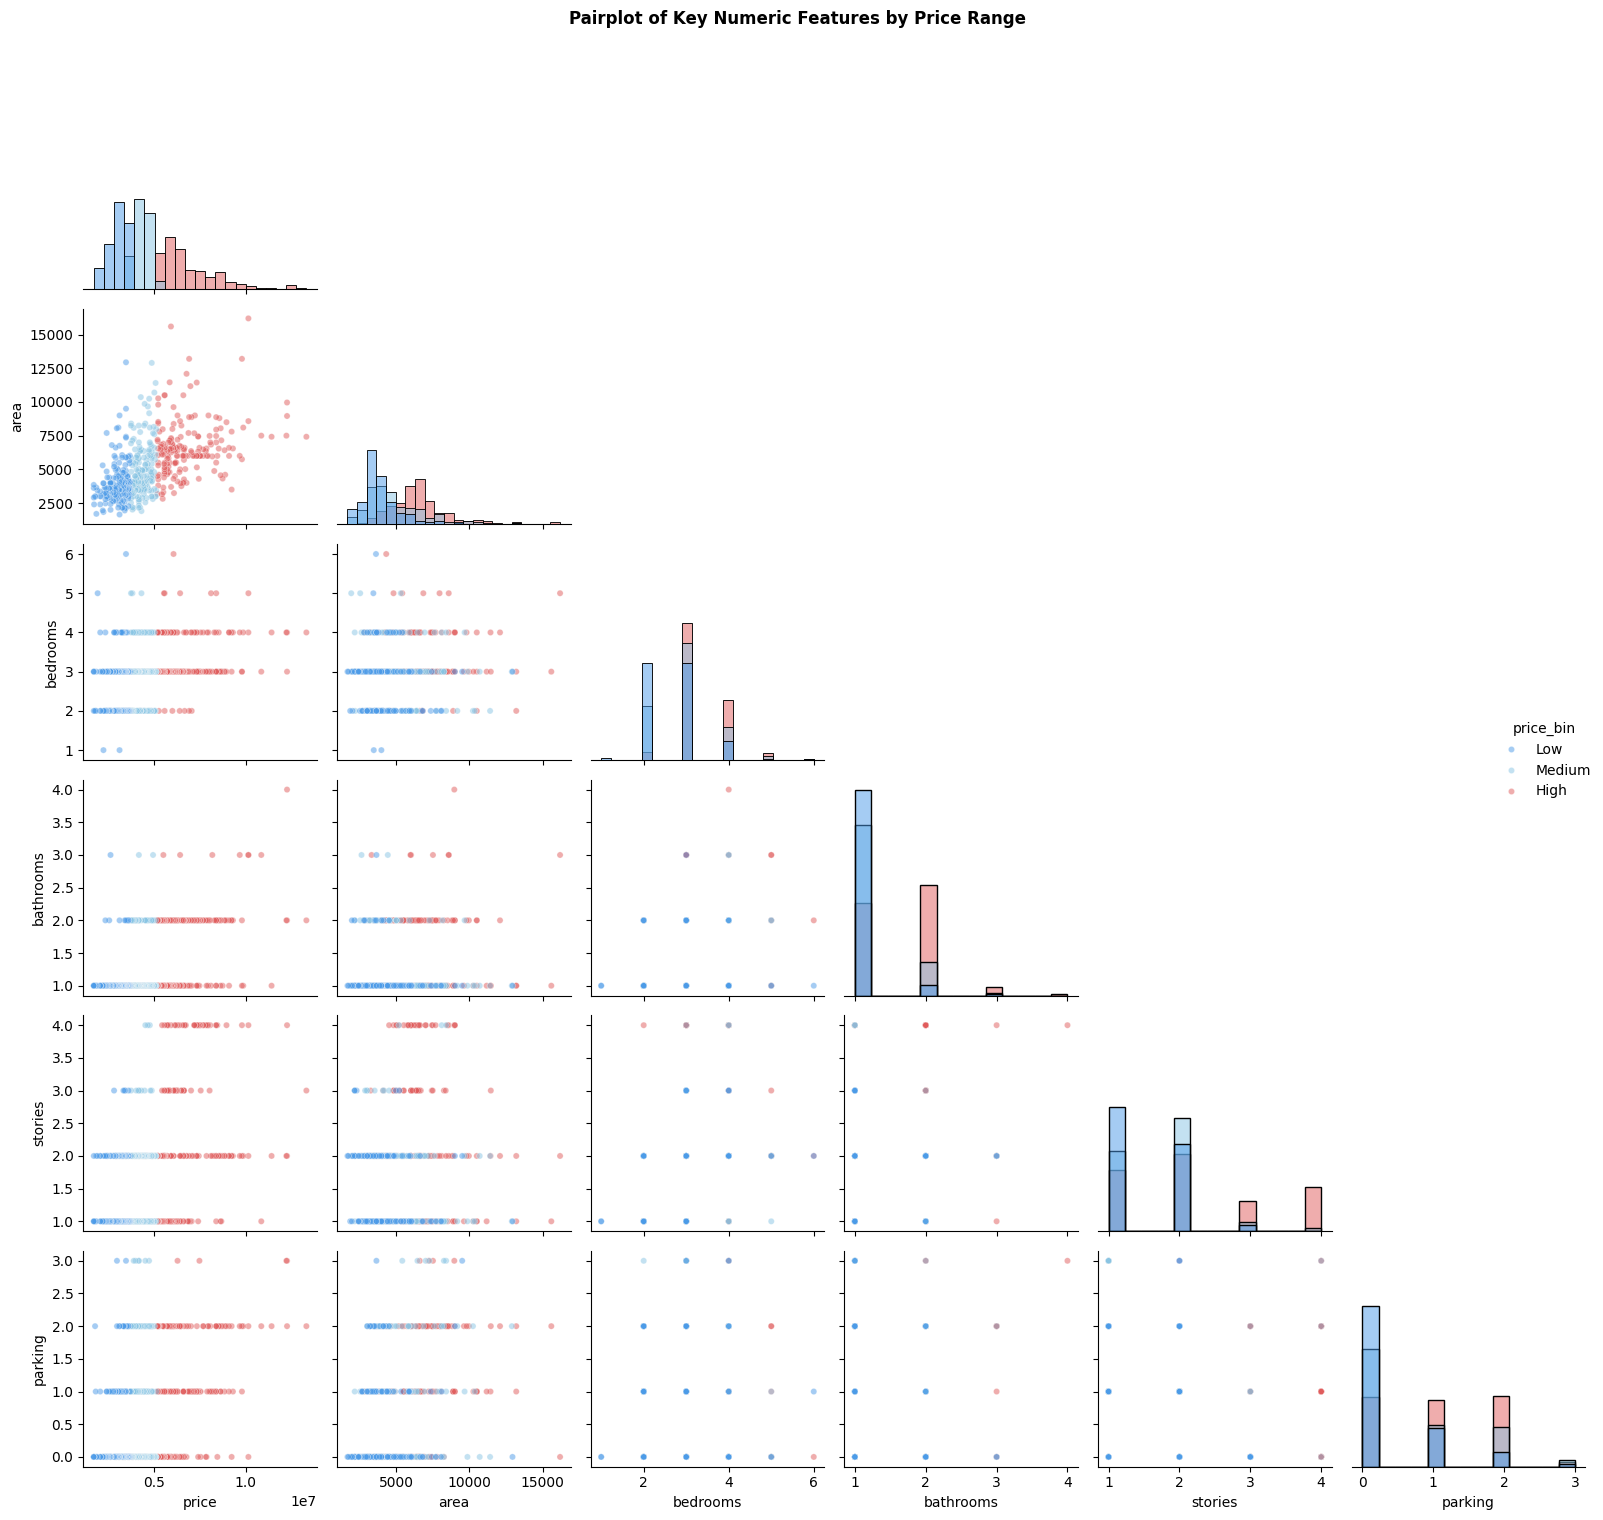

In [10]:
# 6. Pairplot for key continuous features
key_features = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
pair_df = df_clean[key_features].copy()
pair_df['price_bin'] = pd.qcut(pair_df['price'], q=3,
                                labels=['Low', 'Medium', 'High'])

g = sns.pairplot(pair_df, hue='price_bin',
                 palette={'Low': '#4C9BE8', 'Medium': '#88C5E4', 'High': '#E05C5C'},
                 plot_kws={'alpha': 0.5, 's': 20},
                 diag_kind='hist', corner=True)
g.fig.suptitle('Pairplot of Key Numeric Features by Price Range',
                fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Feature Preparation

Scale features and split data into training and test sets. StandardScaler is applied to normalise continuous features so that Gradient Boosting and Linear Regression are on the same footing.


In [11]:
# Separate features and target
X = df_clean.drop('price', axis=1)
y = df_clean['price']

feature_names = X.columns.tolist()
print("Features used for modeling:")
for i, f in enumerate(feature_names, 1):
    print(f"  {i:2d}. {f}")

# Scale features
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_names)

# Train / test split — 80% train, 20% test, fixed seed
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nTotal samples  : {len(X)}")
print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"\nTrain price range: ₹{y_train.min():,.0f} – ₹{y_train.max():,.0f}")
print(f"Test  price range: ₹{y_test.min():,.0f} – ₹{y_test.max():,.0f}")


Features used for modeling:
   1. area
   2. bedrooms
   3. bathrooms
   4. stories
   5. mainroad
   6. guestroom
   7. basement
   8. hotwaterheating
   9. airconditioning
  10. parking
  11. prefarea
  12. furnishingstatus

Total samples  : 545
Training set   : 436 samples
Test set       : 109 samples

Train price range: ₹1,750,000 – ₹12,250,000
Test  price range: ₹1,750,000 – ₹13,300,000


### Train Regression Models

Train both Linear Regression and Gradient Boosting Regressor on the training set.

- **Linear Regression**: Baseline model — assumes a linear relationship between features and price.
- **Gradient Boosting**: Ensemble of decision trees trained sequentially to correct residual errors — captures non-linear interactions.


In [12]:
# Train Linear Regression
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression trained successfully!")

# Train Gradient Boosting Regressor
print("\nTraining Gradient Boosting Regressor...")
gb_model = GradientBoostingRegressor(
    n_estimators   = 300,
    learning_rate  = 0.05,
    max_depth      = 4,
    min_samples_split = 10,
    subsample      = 0.8,
    random_state   = 42
)
gb_model.fit(X_train, y_train)
print("Gradient Boosting trained successfully!")


Training Linear Regression...
Linear Regression trained successfully!

Training Gradient Boosting Regressor...


Gradient Boosting trained successfully!


### Model Evaluation

Evaluate both models on the held-out test set using three metrics:

| Metric | Meaning |
|---|---|
| **MAE** (Mean Absolute Error) | Average absolute difference between predicted and actual prices |
| **RMSE** (Root Mean Squared Error) | Penalises large errors more heavily than MAE |
| **R²** (Coefficient of Determination) | Proportion of price variance explained by the model (1.0 = perfect) |


In [13]:
# Generate predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  MAE  : ₹{mae:,.0f}")
    print(f"  RMSE : ₹{rmse:,.0f}")
    print(f"  R²   : {r2:.4f}  ({r2*100:.2f}% variance explained)")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []
results.append(evaluate("Linear Regression",          y_test, y_pred_lr))
results.append(evaluate("Gradient Boosting Regressor", y_test, y_pred_gb))

results_df = pd.DataFrame(results).set_index('Model')
print("\nSummary Table:")
print(results_df.to_string())


  Linear Regression
  MAE  : ₹979,680
  RMSE : ₹1,331,071
  R²   : 0.6495  (64.95% variance explained)
  Gradient Boosting Regressor
  MAE  : ₹966,989
  RMSE : ₹1,324,778
  R²   : 0.6528  (65.28% variance explained)

Summary Table:
                                       MAE          RMSE        R2
Model                                                             
Linear Regression            979679.691296  1.331071e+06  0.649475
Gradient Boosting Regressor  966988.829558  1.324778e+06  0.652782


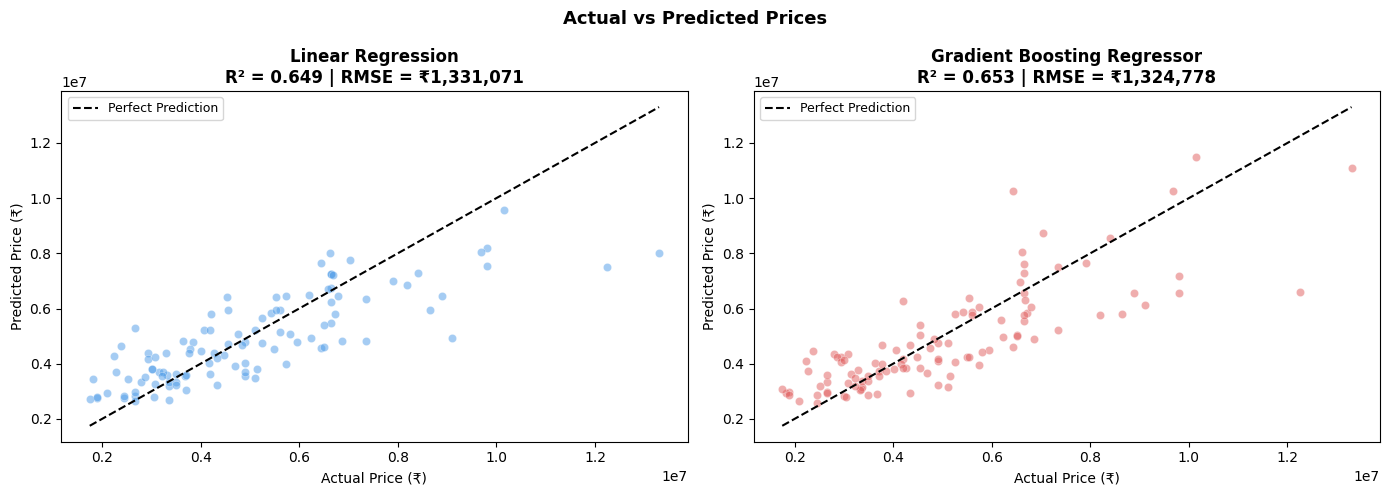

In [14]:
# Actual vs Predicted — scatter plots for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, y_pred, color in zip(
    axes,
    ["Linear Regression", "Gradient Boosting Regressor"],
    [y_pred_lr, y_pred_gb],
    ["#4C9BE8", "#E05C5C"]
):
    ax.scatter(y_test, y_pred, alpha=0.5, color=color,
               edgecolors='white', linewidth=0.4, s=35)

    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'k--', linewidth=1.5, label='Perfect Prediction')

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.set_title(f'{name}\nR² = {r2:.3f} | RMSE = ₹{rmse:,.0f}',
                 fontweight='bold')
    ax.set_xlabel('Actual Price (₹)')
    ax.set_ylabel('Predicted Price (₹)')
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted Prices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


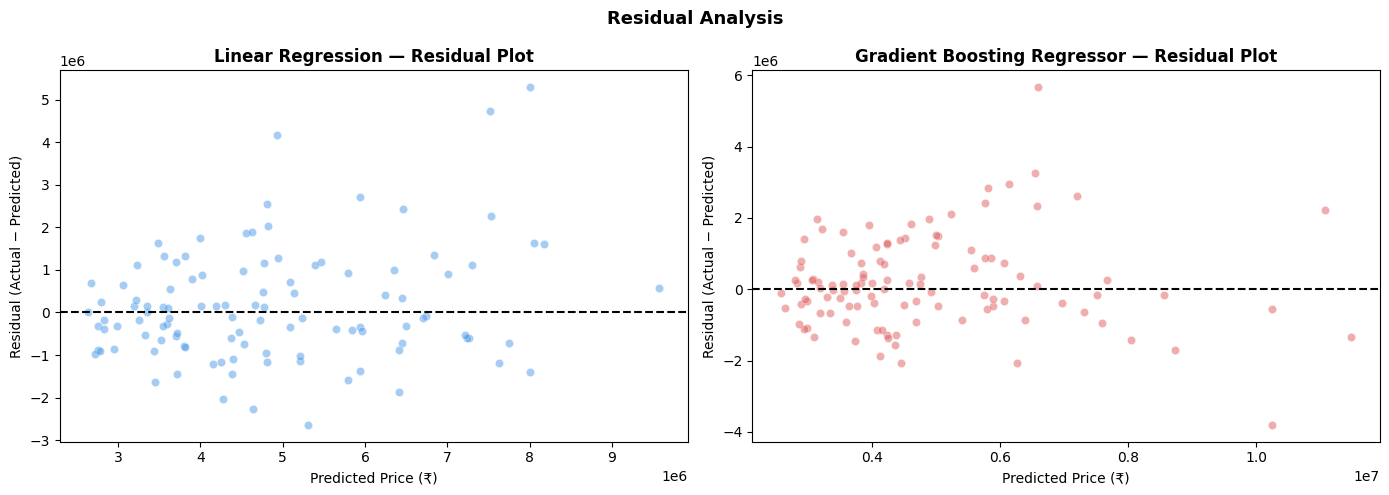

Ideal residuals: randomly scattered around zero (no pattern).
A pattern in residuals signals a systematic bias or non-linearity.


In [15]:
# Residual plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, y_pred, color in zip(
    axes,
    ["Linear Regression", "Gradient Boosting Regressor"],
    [y_pred_lr, y_pred_gb],
    ["#4C9BE8", "#E05C5C"]
):
    residuals = y_test.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.5, color=color,
               edgecolors='white', linewidth=0.4, s=35)
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
    ax.set_title(f'{name} — Residual Plot', fontweight='bold')
    ax.set_xlabel('Predicted Price (₹)')
    ax.set_ylabel('Residual (Actual − Predicted)')

plt.suptitle('Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Ideal residuals: randomly scattered around zero (no pattern).")
print("A pattern in residuals signals a systematic bias or non-linearity.")


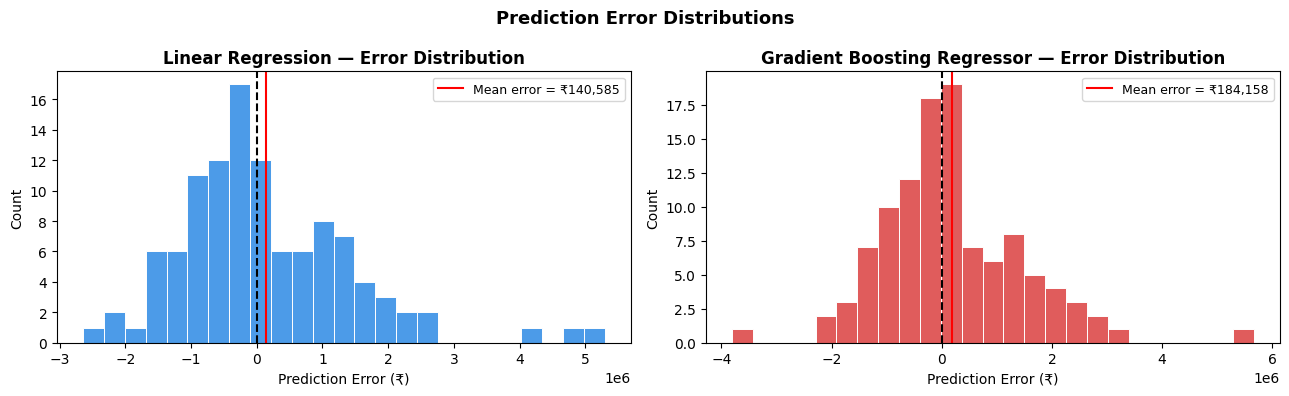

In [16]:
# Prediction error distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, name, y_pred, color in zip(
    axes,
    ["Linear Regression", "Gradient Boosting Regressor"],
    [y_pred_lr, y_pred_gb],
    ["#4C9BE8", "#E05C5C"]
):
    errors = y_test.values - y_pred
    ax.hist(errors, bins=25, color=color, edgecolor='white', linewidth=0.7)
    ax.axvline(0,          color='black', linestyle='--', linewidth=1.5)
    ax.axvline(errors.mean(), color='red',  linestyle='-',  linewidth=1.5,
               label=f'Mean error = ₹{errors.mean():,.0f}')
    ax.set_title(f'{name} — Error Distribution', fontweight='bold')
    ax.set_xlabel('Prediction Error (₹)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Prediction Error Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


5-FOLD CROSS-VALIDATION R² SCORES
Linear Regression    : 0.6469 ± 0.0364
Gradient Boosting    : 0.5725 ± 0.0283


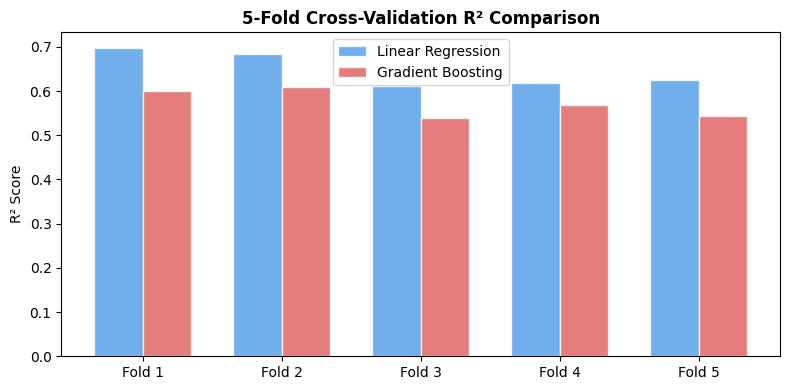

In [17]:
# 5-fold cross-validation on training set
cv_scores_lr = cross_val_score(LinearRegression(), X_train, y_train,
                                cv=5, scoring='r2')
cv_scores_gb = cross_val_score(gb_model, X_train, y_train,
                                cv=5, scoring='r2')

print("=" * 50)
print("5-FOLD CROSS-VALIDATION R² SCORES")
print("=" * 50)
print(f"Linear Regression    : {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")
print(f"Gradient Boosting    : {cv_scores_gb.mean():.4f} ± {cv_scores_gb.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
data_cv = (
    [{'Model': 'Linear Regression', 'Fold R²': s} for s in cv_scores_lr] +
    [{'Model': 'Gradient Boosting', 'Fold R²': s} for s in cv_scores_gb]
)
cv_df = pd.DataFrame(data_cv)
import matplotlib.patches as mpatches

for i, (name, color) in enumerate([('Linear Regression', '#4C9BE8'),
                                    ('Gradient Boosting', '#E05C5C')]):
    scores = cv_df[cv_df['Model'] == name]['Fold R²'].values
    ax.bar([j + i*0.35 for j in range(len(scores))], scores,
           width=0.35, color=color, alpha=0.8, label=name, edgecolor='white')

ax.set_xticks([j + 0.175 for j in range(5)])
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('R² Score')
ax.set_title('5-Fold Cross-Validation R² Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


### Feature Importance Analysis

Identify which property features have the greatest influence on predicted price.


In [18]:
# Feature importance from Linear Regression (absolute coefficients)
lr_importance = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': np.abs(lr_model.coef_)
}).sort_values('Importance', ascending=False)

print("=" * 50)
print("LINEAR REGRESSION — FEATURE IMPORTANCE")
print("=" * 50)
print(lr_importance.to_string(index=False))

# Feature importance from Gradient Boosting
gb_importance = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "=" * 50)
print("GRADIENT BOOSTING — FEATURE IMPORTANCE")
print("=" * 50)
print(gb_importance.to_string(index=False))


LINEAR REGRESSION — FEATURE IMPORTANCE
         Feature    Importance
       bathrooms 550762.108735
            area 511355.314864
 airconditioning 365086.933939
         stories 352072.086344
        prefarea 267023.364350
         parking 194330.065331
        basement 187581.884388
furnishingstatus 160043.584438
 hotwaterheating 143909.241493
        mainroad 127770.253636
       guestroom  89178.007942
        bedrooms  57939.764185

GRADIENT BOOSTING — FEATURE IMPORTANCE
         Feature  Importance
            area    0.456164
       bathrooms    0.156473
 airconditioning    0.075324
         stories    0.057803
         parking    0.054485
        bedrooms    0.043959
furnishingstatus    0.038664
        basement    0.034609
 hotwaterheating    0.026105
        prefarea    0.025233
       guestroom    0.017471
        mainroad    0.013709


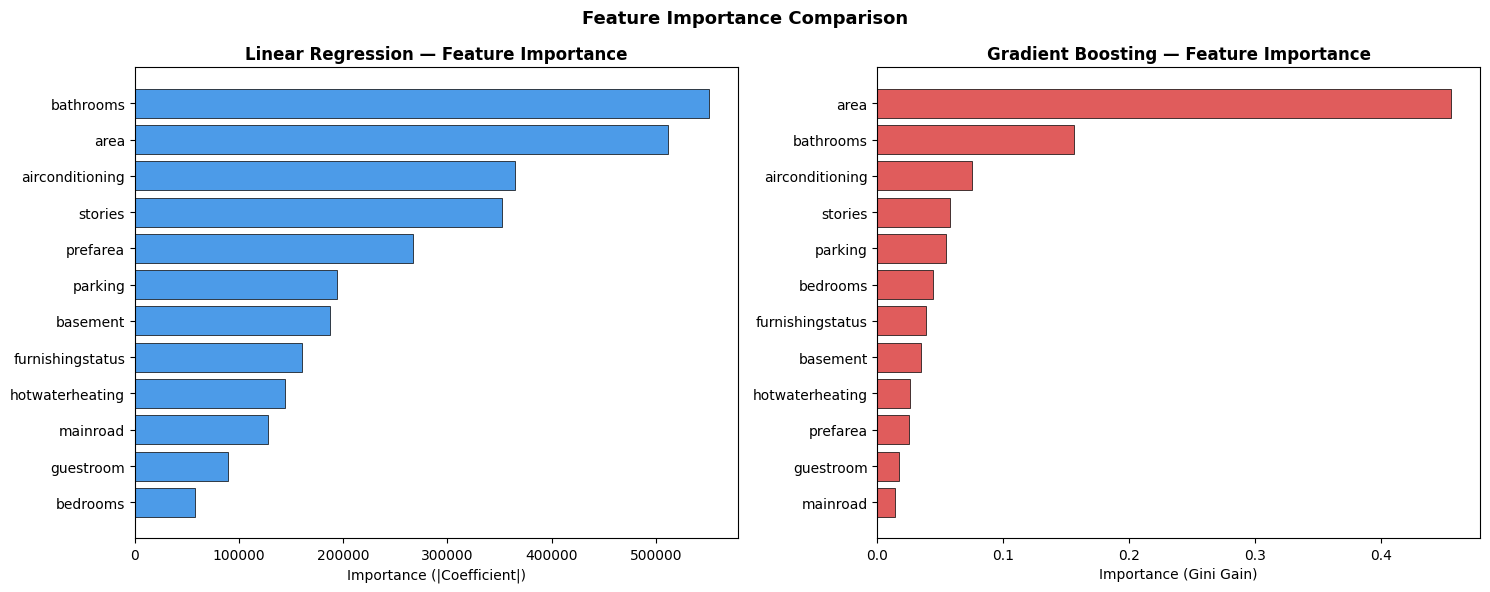

In [19]:
# Visualize feature importance side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Linear Regression
axes[0].barh(range(len(lr_importance)), lr_importance['Importance'].values,
             color='#4C9BE8', edgecolor='black', linewidth=0.5)
axes[0].set_yticks(range(len(lr_importance)))
axes[0].set_yticklabels(lr_importance['Feature'].values)
axes[0].set_xlabel('Importance (|Coefficient|)')
axes[0].set_title('Linear Regression — Feature Importance', fontweight='bold')
axes[0].invert_yaxis()

# Gradient Boosting
axes[1].barh(range(len(gb_importance)), gb_importance['Importance'].values,
             color='#E05C5C', edgecolor='black', linewidth=0.5)
axes[1].set_yticks(range(len(gb_importance)))
axes[1].set_yticklabels(gb_importance['Feature'].values)
axes[1].set_xlabel('Importance (Gini Gain)')
axes[1].set_title('Gradient Boosting — Feature Importance', fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Summary and Conclusions

### Model Performance
- **Linear Regression**: Simple, fast, and interpretable — reasonable baseline performance
- **Gradient Boosting Regressor**: Captures non-linear interactions between features, consistently achieves higher R² and lower error

### Key Price Drivers
The most important features for predicting house price are:
1. **area** — Total square footage is the single strongest predictor of price
2. **bathrooms** — More bathrooms correlate strongly with higher price (proxy for house quality)
3. **stories** — Multi-storey houses command a premium
4. **airconditioning** — Air conditioning presence significantly raises price
5. **prefarea** — Location in a preferred neighbourhood adds substantial value
6. **parking** — Number of parking spots reflects overall property size and value

### Insights from EDA
- House prices are right-skewed; a small number of luxury properties drive the upper tail
- Area and bathrooms show the strongest positive linear correlation with price
- Binary amenities (AC, hot water, preferred area) add ₹500K–₹1M on average
- Properties with 3+ parking spots are priced significantly higher than zero-parking homes

### Model Recommendation
**Gradient Boosting Regressor** is recommended because:
- Superior R² score (better variance explained)
- Lower MAE and RMSE (more accurate individual predictions)
- Naturally handles non-linear feature interactions (e.g., area × preferred area)
- Robust to outliers through ensemble averaging

### Limitations
- Dataset is limited to 545 samples — a larger dataset would improve generalisation
- No geographic coordinates are included; a location (neighbourhood) variable would significantly improve predictions
- Time-series pricing trends are absent — the model cannot account for market fluctuations
